# PART 3: FILTERING POSSIBLE NEW LOCATIONS

In part 3 of the notebook we are trying to filter possible suitable new locations for building a wind farm. We do that by compining a set of different information we managed to acquire for topological data as well as data about the elericity grid all around Europe.

## DATA COLLECTION

We gathered the data from the [https://ec.europa.eu/eurostat/web/gisco/geodata/reference-data/land-cover]

GISCO - the Geographic Information System of the COmmission - localise, analyse, visualise is an inclusive dataset contains core geographical data covering the whole of Europe, such as administrative boundaries, NUTS classification and land use data.


In [97]:
!pip install geopandas

In [1]:
import geopandas as gpd
import pandas as pd
gdf = gpd.read_file('C:/Users/30698/Desktop/DTU/Advanced BA/Project/LUCA_PT_2009.shp')

In [2]:
land_use_data = pd.DataFrame(gdf)
land_use_data.to_csv('land_use_data.csv', index=False)

In [58]:
land_use_data.head()

,LUCA_PT_ID,SURV_DATE,LUCA_OBSR_,LUCA_OBSR1,GPS_PROJ,GPS_PREC,LAT_GPS,LON_GPS,OBSR_DIST,LUCA_DIRE_,...,TRANS,ELEV,AREA,EAST,NORT,LON,LAT,geometry,land use data,Category
0,46702602,2-Jan-09,2.0,3.0,X,8888.0,89.0,89.0,88888.0,1.0,...,"PI(,E20,C20,)PI, , , , , , , , , , , , , , , ,...",945,3376.87552,4670000,2602000,14.539452,46.435266,POINT (14.53945 46.43527),Arable land and permanent crops,Arable land and permanent crops
1,46422610,06JUL2009,1.0,1.0,WGS84,9.0,47.0,14.0,1.0,1.0,...,"C10,C30,31,C10,32,C10, , , , , , , , , , , , ,...",680,2026.70874,4642000,2610000,14.181589,46.521961,POINT (14.18159 46.52196),Arable land and permanent crops,Arable land and permanent crops
2,46582612,29MAY2009,1.0,1.0,WGS84,5.0,47.0,14.0,1.0,1.0,...,"C10,C30, , , , , , , , , , , , , , , , , , , ,...",897,2026.70874,4658000,2612000,14.391085,46.531627,POINT (14.39109 46.53163),Arable land and permanent crops,Arable land and permanent crops
3,46302614,07JUL2009,1.0,1.0,WGS84,4.0,47.0,14.0,1.0,1.0,...,"E20,14,E20,B71,E10,62,A,13,E20,B71,E10, , , , ...",500,2026.70874,4630000,2614000,14.028261,46.563888,POINT (14.02826 46.56389),Continuous urban fabric,Continuous urban fabric
4,46342614,29JUN2009,1.0,1.0,WGS84,3.0,47.0,14.0,0.0,1.0,...,"E20,61,C30,B16,C10,E20,10,E20, , , , , , , , ,...",535,2026.70874,4634000,2614000,14.080315,46.561923,POINT (14.08032 46.56192),Continuous urban fabric,Continuous urban fabric


# DATA PREPARATION

In [3]:
# create a new column based on the value of the 'Age' column
land_use_data['land use data'] = ''
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U120', 'land use data'] = 'Arable land and permanent crops'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U111', 'land use data'] = 'Continuous urban fabric'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U361', 'land use data'] = 'Non-irrigated arable land'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U370', 'land use data'] = 'Fruit trees and berry plantations'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U317', 'land use data'] = 'Land principally occupied by agriculture, with significant areas of natural vegetation'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U112', 'land use data'] = 'Discontinuous urban fabric'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U312', 'land use data'] = 'Pastures'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U400', 'land use data'] = 'Open spaces with little or no vegetation'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U130', 'land use data'] = 'Mixed crops'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U340', 'land use data'] = 'Moors, heathland and sclerophyllous vegetation'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U364', 'land use data'] = 'Intensive olive groves'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U362', 'land use data'] = 'Sparsely vegetated areas'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U350', 'land use data'] = 'Glaciers and perpetual snow'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U313', 'land use data'] = 'Complex cultivation patterns'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U314', 'land use data'] = 'Land principally occupied by agriculture, with significant areas of natural and seminatural vegetation'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U113', 'land use data'] = 'Industrial or commercial units'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U311', 'land use data'] = 'Broad-leaved forest'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U321', 'land use data'] = 'Natural grassland and sparsely vegetated areas'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U150', 'land use data'] = 'Inland marshes'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U318', 'land use data'] = 'Transitional woodland/shrub'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U322', 'land use data'] = 'Moors and heathland'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U227', 'land use data'] = 'Inland sand dunes'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U226', 'land use data'] = 'Maritime dunes'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U330', 'land use data'] = 'Beaches, dunes, sands'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U316', 'land use data'] = 'Natural grasslands'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U140', 'land use data'] = 'Rice fields'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U223', 'land use data'] = 'Vineyards'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U363', 'land use data'] = 'Transitional woodland/shrub - olive groves'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U224', 'land use data'] = 'Fruit trees and berry plantations'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U210', 'land use data'] = 'Water courses'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U221', 'land use data'] = 'Sea and ocean'
land_use_data.loc[land_use_data['LUCA_LUSE_'] == 'U222', 'land use data'] = 'Coastal lagoons'

land_use_data.head(2)






,LUCA_PT_ID,SURV_DATE,LUCA_OBSR_,LUCA_OBSR1,GPS_PROJ,GPS_PREC,LAT_GPS,LON_GPS,OBSR_DIST,LUCA_DIRE_,...,PHOT_CONF_,TRANS,ELEV,AREA,EAST,NORT,LON,LAT,geometry,land use data
0,46702602,2-Jan-09,2.0,3.0,X,8888.0,89.0,89.0,88888.0,1.0,...,0.0,"PI(,E20,C20,)PI, , , , , , , , , , , , , , , ,...",945,3376.87552,4670000,2602000,14.539452,46.435266,POINT (14.53945 46.43527),Arable land and permanent crops
1,46422610,06JUL2009,1.0,1.0,WGS84,9.0,47.0,14.0,1.0,1.0,...,2.0,"C10,C30,31,C10,32,C10, , , , , , , , , , , , ,...",680,2026.70874,4642000,2610000,14.181589,46.521961,POINT (14.18159 46.52196),Arable land and permanent crops


In [4]:
land_use_data.shape

(234707, 52)

In [5]:
land_use_data.columns

Index(['LUCA_PT_ID', 'SURV_DATE', 'LUCA_OBSR_', 'LUCA_OBSR1', 'GPS_PROJ',
       'GPS_PREC', 'LAT_GPS', 'LON_GPS', 'OBSR_DIST', 'LUCA_DIRE_',
       'LUCA_LCOV_', 'LUCA_LCOV1', 'LUCA_RADI_', 'LUCA_LUSE_', 'LUCA_LUSE1',
       'LUCA_SPCS_', 'LUCA_PERC_', 'LUCA_SPCS1', 'LUCA_PERC1', 'LUCA_AREA_',
       'LUCA_TREE_', 'LUCA_FEAT_', 'LAND_GRAZ_', 'LUCA_WTMN_', 'LUCA_IRRI_',
       'LUCA_IRRI1', 'LUCA_IRR_1', 'LAT_LAEA', 'LON_LAEA', 'LUCA_STRT_',
       'LUCA_STRT1', 'NUTS_CODE', 'STAT_LEVL_', 'PHOT_PT_FL', 'PHOT_CROP_',
       'PHOT_N_FLA', 'PHOT_E_FLA', 'PHOT_S_FLA', 'PHOT_W_FLA', 'PHOT_IRRI_',
       'PHOT_TRSC_', 'PHOT_SOIL_', 'PHOT_CONF_', 'TRANS', 'ELEV', 'AREA',
       'EAST', 'NORT', 'LON', 'LAT', 'geometry', 'land use data'],
      dtype='object')

In [6]:
pd.options.display.max_rows = None

In [7]:
land_use_data['NUTS_CODE'].unique().tolist()

['AT213',
 'AT211',
 'AT212',
 'AT225',
 'AT333',
 'AT224',
 'AT221',
 'AT334',
 'AT226',
 'AT341',
 'AT113',
 'AT332',
 'AT335',
 'AT322',
 'AT223',
 'AT342',
 'AT331',
 'AT111',
 'AT315',
 'AT222',
 'AT323',
 'AT122',
 'AT314',
 'AT121',
 'AT112',
 'AT311',
 'AT312',
 'AT127',
 'AT313',
 'AT123',
 'AT126',
 'AT124',
 'AT125',
 'BE341',
 'BE345',
 'BE344',
 'BE351',
 'BE342',
 'BE353',
 'BE326',
 'BE343',
 'BE322',
 'BE331',
 'BE335',
 'BE323',
 'BE352',
 'BE325',
 'BE332',
 'BE336',
 'BE327',
 'BE321',
 'BE310',
 'BE223',
 'BE242',
 'BE324',
 'BE231',
 'BE235',
 'BE241',
 'BE100',
 'BE253',
 'BE254',
 'BE221',
 'BE257',
 'BE234',
 'BE256',
 'BE222',
 'BE252',
 'BE212',
 'BE232',
 'BE211',
 'BE258',
 'BE213',
 'BE236',
 'BE251',
 'BE233',
 'CZ031',
 'CZ064',
 'CZ063',
 'CZ072',
 'CZ032',
 'CZ020',
 'CZ071',
 'CZ053',
 'CZ080',
 'CZ041',
 'CZ010',
 'CZ042',
 'CZ052',
 'CZ051',
 'DE21D',
 'DE139',
 'DE13A',
 'DE27A',
 'DE147',
 'DE21F',
 'DE21N',
 'DE216',
 'DE27E',
 'DE215',
 'DE148',


## Topographical Filtering

The LUCA (Land Use and Land Cover Area Frame Survey) land use codes are a set of standardized codes that represent different types of land use and land cover. These codes are used to classify and describe the different land use and land cover types in a given area.

The LUCA land use codes consist of a 2-digit category code followed by a 3-digit subclass code. The category code represents the general land use category, such as agricultural land or urban land, while the subclass code provides more specific information about the land use or land cover type within that category.

Based on the given list of LUCA land use codes, areas that may be suitable for building a wind farm include the following: ['U361', 'U317', 'U130', 'U340', 'U313', 'U314', 'U311', 'U321', 'U318', 'U322', 'U316', 'U363', 'U223'] as these land use types may have minimal conflicting land uses or environmental constraints. 

For example, U316 corresponds to natural grass land. Natural grasslands often pose a favorable location for wind farms because of the wind availability that they offer, the gently slopping terrains (makes it easier to install and maintain them), the limited environmental impact since grasslands are considered to be less ecologically sensitive than other ecosystems and finaly because of theminimal land use conflicts since they can coexist with agriculture  or grazing. For all these reasons we filter such locations 'in' and we are using them to predict the potential new locations.

On the other hand, U111 corresponds to continues urban fabric. It is not sensible to built wind farms close to urban areas since there are many limitatations spanning from the lack of space and unobstacled wind flow, noise generation and visual pollution. That s why we filtered out such locations as they are unsuitable for wind farm projects.

In the same way we decided upon which land use types are appropriate and which aren't and we filtered the data accordingly.


In [8]:
acceptable_land_use_type = ['U361', 'U317', 'U130', 'U340', 'U313', 'U314', 'U311', 'U321', 'U318', 'U322', 'U316', 'U363', 'U223']

data_filtered = land_use_data[land_use_data['LUCA_LUSE_'].isin(acceptable_land_use_type)]

columns_to_keep = ['LUCA_LUSE_', 'NUTS_CODE', 'ELEV', 'AREA', 'EAST', 'NORT', 'LON', 'LAT', 'land use data']
data_filtered = data_filtered[columns_to_keep]


In [9]:
data_filtered.head()

,LUCA_LUSE_,NUTS_CODE,ELEV,AREA,EAST,NORT,LON,LAT,land use data
13,U361,AT211,654,2026.70874,4644000,2620000,14.214710,46.610829,Non-irrigated arable land
17,U361,AT211,429,2026.70874,4638000,2622000,14.137962,46.631844,Non-irrigated arable land
39,U317,AT225,276,2225.53184,4752000,2638000,15.636998,46.708024,"Land principally occupied by agriculture, with..."
120,U130,AT335,873,3974.52317,4502000,2706000,12.398441,47.441224,Mixed crops
126,U340,AT342,509,725.21276,4302000,2710000,9.747978,47.503322,"Moors, heathland and sclerophyllous vegetation"


In [10]:
data_filtered.shape

(7211, 9)

The first two letters of the NUTS_CODE classification correspond country codes in EU. We decided to aim our efforts towards finding potential new locations to build a wind farm in Italy. That is why below we filter the dataset, selecting only the rows that correspond to land use data in Italy. 

In [52]:
locations_to_keep = ['ITF65',
 'ITF63',
 'ITF64',
 'ITF62',
 'ITF61',
 'ITF51',
 'ITF35',
 'ITF45',
 'ITF52',
 'ITF43',
 'ITF44',
 'ITF33',
 'ITF34',
 'ITF42',
 'ITF31',
 'ITF32',
 'ITF41',
 'ITE44',
 'ITE45',
 'ITE43',
 'ITF22',
 'ITF21',
 'ITF11',
 'ITF14',
 'ITE42',
 'ITE41',
 'ITF13',
 'ITE1A',
 'ITE22',
 'ITF12',
 'ITE21',
 'ITE34',
 'ITE16',
 'ITE33',
 'ITE19',
 'ITE17',
 'ITE18',
 'ITE32',
 'ITE31',
 'ITE14',
 'ITE12',
 'ITD58',
 'ITE13',
 'ITC31',
 'ITC32',
 'ITD59',
 'ITE15',
 'ITC34',
 'ITD55',
 'ITD57',
 'ITD54',
 'ITE11',
 'ITC16',
 'ITC33',
 'ITD53',
 'ITD52',
 'ITC18',
 'ITD56',
 'ITD51',
 'ITC17',
 'ITC48',
 'ITC11',
 'ITD37',
 'ITC4A',
 'ITC4B',
 'ITC49',
 'ITD31',
 'ITD36',
 'ITC12',
 'ITC47',
 'ITD32',
 'ITC15',
 'ITC45',
 'ITD35',
 'ITC46',
 'ITC13',
 'ITC41',
 'ITD44',
 'ITC20',
 'ITD34',
 'ITD20',
 'ITC42',
 'ITD42',
 'ITD43',
 'ITD41',
 'ITC14',
 'ITD33',
 'ITC44',
 'ITD10',
 'ITG18',
 'ITG19',
 'ITG15',
 'ITG17',
 'ITG14',
 'ITG16',
 'ITG12',
 'ITG11',
 'ITG13',
 'ITG27',
 'ITG2C',
 'ITG2B',
 'ITG28',
 'ITG2A',
 'ITG26',
 'ITG25',
 'ITG29']

# Filter the rows based on the LUCA_LUSE codes
filtered_IT = data_filtered[data_filtered['NUTS_CODE'].isin(locations_to_keep)]


In [53]:
filtered_IT.head()

,LUCA_LUSE_,NUTS_CODE,ELEV,AREA,EAST,NORT,LON,LAT,land use data
8656,U361,ITF61,483,6651.20382,4872000,1908000,16.432834,40.056072,Non-irrigated arable land
8769,U340,ITF42,499,5131.69236,4834000,2018000,16.085300,41.075915,"Moors, heathland and sclerophyllous vegetation"
8800,U340,ITE44,10,2251.97078,4568000,2050000,12.947639,41.508231,"Moors, heathland and sclerophyllous vegetation"
8801,U340,ITE45,39,3238.15241,4640000,2050000,13.805810,41.479173,"Moors, heathland and sclerophyllous vegetation"
8828,U361,ITE43,441,5352.79290,4544000,2082000,12.673964,41.805307,Non-irrigated arable land


In [54]:
filtered_IT=filtered_IT.reset_index(drop=True)

In [55]:
filtered_IT.head()

,LUCA_LUSE_,NUTS_CODE,ELEV,AREA,EAST,NORT,LON,LAT,land use data
0,U361,ITF61,483,6651.20382,4872000,1908000,16.432834,40.056072,Non-irrigated arable land
1,U340,ITF42,499,5131.69236,4834000,2018000,16.085300,41.075915,"Moors, heathland and sclerophyllous vegetation"
2,U340,ITE44,10,2251.97078,4568000,2050000,12.947639,41.508231,"Moors, heathland and sclerophyllous vegetation"
3,U340,ITE45,39,3238.15241,4640000,2050000,13.805810,41.479173,"Moors, heathland and sclerophyllous vegetation"
4,U361,ITE43,441,5352.79290,4544000,2082000,12.673964,41.805307,Non-irrigated arable land


# Gathering historical data

In [56]:
!pip install meteostat

The function "calculate_average_wind_speed" calculates the average wind speed for a given set of latitude and longitude coordinates over a 13 year time period, using nearby weather station data obtained through the Meteostat API.

In [57]:
# Import Meteostat library and dependencies
from datetime import datetime,  timedelta
import matplotlib.pyplot as plt
from meteostat import Point, Daily, Hourly, Monthly, Stations
import matplotlib.pyplot as plt

In [58]:
def calculate_average_wind_speed(df, start_date, end_date):

    wspd_df = pd.DataFrame(columns=['wspd'])

    for index, row in df.iterrows():
        lon, lat = row['LON'], row['LAT']

        stations = Stations()
        stations = stations.nearby(lat, lon)
        station = stations.fetch(1)

        # Query Meteostat API for daily wind data
        data = Daily(station, start_date, end_date).fetch()
        
        # Remove rows with missing wind speed values
        datadrop = data.dropna(subset=['wspd'])

        # Calculate average wind speed for the location
        avg_wind_speed = datadrop['wspd'].mean()

        # Add result to the dataframe of results
        wspd_df = wspd_df.append({'wspd': avg_wind_speed}, ignore_index=True)

    return wspd_df

In [68]:
start_date = datetime(2010, 1, 1)
end_date = datetime(2022, 12, 31)
wspd_df=calculate_average_wind_speed(filtered_IT, start_date, end_date)

In [47]:
wspd_df

,wspd
0,9.510534
1,7.355093
2,8.571448
3,7.206786
4,10.057409
5,12.608873
6,NaN
7,NaN
8,8.186922
9,7.523824


In [69]:
filtered_IT = filtered_IT.join(wspd_df,rsuffix='_other')

In [104]:
filtered_IT = filtered_IT.drop('wspd_other', axis=1)

In [105]:
filtered_IT.head()


,LUCA_LUSE_,NUTS_CODE,ELEV,AREA,EAST,NORT,LON,LAT,land use data,wspd,proximity
0,U361,ITF61,483,6651.20382,4872000,1908000,16.432834,40.056072,Non-irrigated arable land,9.510534,1360.731790
1,U340,ITF42,499,5131.69236,4834000,2018000,16.085300,41.075915,"Moors, heathland and sclerophyllous vegetation",7.355093,364.144490
2,U340,ITE44,10,2251.97078,4568000,2050000,12.947639,41.508231,"Moors, heathland and sclerophyllous vegetation",8.571448,164.435939
3,U340,ITE45,39,3238.15241,4640000,2050000,13.805810,41.479173,"Moors, heathland and sclerophyllous vegetation",7.206786,231.940398
4,U361,ITE43,441,5352.79290,4544000,2082000,12.673964,41.805307,Non-irrigated arable land,10.057409,132.545945


In [72]:
filtered_IT = filtered_IT.dropna()
filtered_IT.head()

,LUCA_LUSE_,NUTS_CODE,ELEV,AREA,EAST,NORT,LON,LAT,land use data,wspd,wspd_other
0,U361,ITF61,483,6651.20382,4872000,1908000,16.432834,40.056072,Non-irrigated arable land,9.510534,9.510534
1,U340,ITF42,499,5131.69236,4834000,2018000,16.085300,41.075915,"Moors, heathland and sclerophyllous vegetation",7.355093,7.355093
2,U340,ITE44,10,2251.97078,4568000,2050000,12.947639,41.508231,"Moors, heathland and sclerophyllous vegetation",8.571448,8.571448
3,U340,ITE45,39,3238.15241,4640000,2050000,13.805810,41.479173,"Moors, heathland and sclerophyllous vegetation",7.206786,7.206786
4,U361,ITE43,441,5352.79290,4544000,2082000,12.673964,41.805307,Non-irrigated arable land,10.057409,10.057409


In [91]:
filtered_IT.shape

(409, 11)

## Filtering with respect to proximity to electricity grid

The potencial new wind farms must be located close to existing electrical grid in order to reduce the cost in building long transmission lines and energy loss during the transmission. However, determining the appropriate distance from a power grid depends on several factors, such as project size, transmission infrastructure, land availability and environmental considerations. 

In general, small wind farms are connected to medium voltage grids, which ranges from 10 to 60 kV, while large wind farms are connected to high voltage grids that exceed 70 kV. Although high-voltage data is often available, medium and low voltage data are often non-existent or unavailable. To address this problem, ESMAP, Facebook and other organizations collaborated to develop the Gridfinder Python package to identify and extract electrical network structures. Gridfinder uses open source power grid data from OpenStreetMap and employs night-time light imagery, road networks, and human activity data to predict the missing power grids. The model tipically has an accuracy rate of 75% at 1 km. 

The dataset utilized in the notebook has medium and high electrical grids from two different sources OpenStreetMap and the missing electrical grids using the Gridfinder model.

In [73]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely.wkt
import numpy as np

In [74]:
#Dataset in geopackage format that contains high and medium voltaje electrical grids around the world
# Download: grid.gpkg
data = gpd.read_file(r"C:\Users\30698\Desktop\DTU\Advanced BA\Project\grid.gpkg")

To identify the electrical grids based on country, also a new geodata was downloaded that contains the boundaries of each country. However, due to the resolution of the data and territorial disputes between nations, the accuracy of the country boundaries is not entirely reliable

In [75]:
#Country boundaries to clip the geopackage and just take the electrical grid of a country
country_boundaries = gpd.read_file(r"C:\Users\30698\Desktop\DTU\Advanced BA\Project\WB_countries_Admin0_10m.shp")

In [76]:
data.head()

,source,geometry
0,gridfinder,"LINESTRING (128.88542 71.73125, 128.87708 71.7..."
1,gridfinder,"LINESTRING (128.88542 71.73125, 128.89375 71.7..."
2,gridfinder,"LINESTRING (128.88542 71.70208, 128.88125 71.7..."
3,openstreetmap,"LINESTRING (128.88958 71.70208, 128.88542 71.7..."
4,openstreetmap,"LINESTRING (128.88542 71.69792, 128.88542 71.7..."


In [77]:
#Coordinates are in WGS84 format (longitude,latitude)
#-90 to 90 for latitude and -180 to 180 for longitude.
print('Full coordinates of row 0: ',data['geometry'][1])
print('Number of rows: ',len(data))

Full coordinates of row 0:  LINESTRING (128.8854176977001 71.73125057381806, 128.8937510311001 71.73958390721805)
Number of rows:  3678243


In [78]:
#LineString is a 1D geometrical object that represent a sequence of points
print(data.head())

          source                                           geometry
0     gridfinder  LINESTRING (128.88542 71.73125, 128.87708 71.7...
1     gridfinder  LINESTRING (128.88542 71.73125, 128.89375 71.7...
2     gridfinder  LINESTRING (128.88542 71.70208, 128.88125 71.7...
3  openstreetmap  LINESTRING (128.88958 71.70208, 128.88542 71.7...
4  openstreetmap  LINESTRING (128.88542 71.69792, 128.88542 71.7...


In [79]:
#sources from which the power grid was extracted
sources = data['source'].unique()
sources

array(['gridfinder', 'openstreetmap'], dtype=object)

<AxesSubplot:>

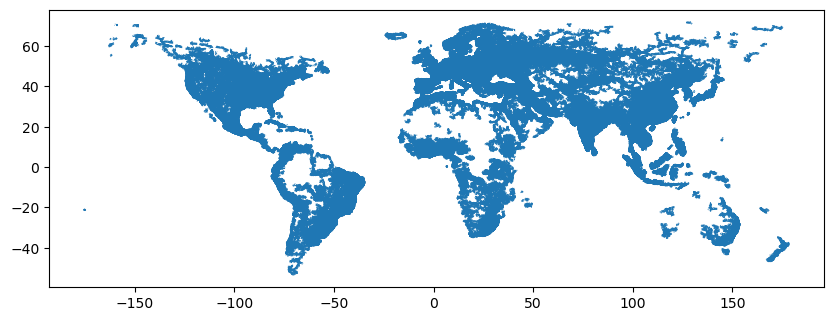

In [80]:
data.plot(figsize=(10, 20))

The whole medium and high voltage electrical grid in the world. For instance, we can observe hat Europe is a highly electrified continent, with a well-developed and interconnected grid system. In contrast, large areas of Africa still lack high and medium electrical grids, highlighting the need for continued investment in large energy infrastructure in these regions. 

# OpenStreetMap and Gridfinder data

Comparing the OpenStreetMap data with the Gridfinder model's electrical grid predictions.

In [ ]:
#Openstreetmap is a open-source mapping project
#Grindfinder is a model to predict electrical grid using open-source dataset (satelital light at night, path of roads, human activity,etc)
gridfinder = data[data['source'] == sources[0]]
openstreetmap = data[data['source'] == sources[1]]

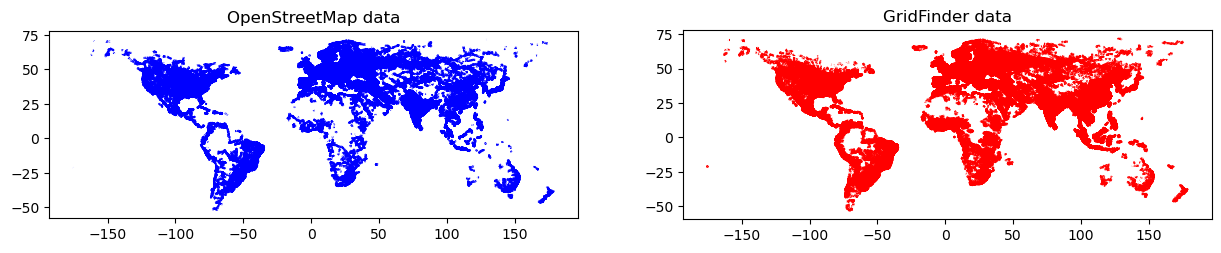

In [82]:
# Plot of the data from openstreetmap and gridfinde
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15,10))

openstreetmap.plot(ax=ax1, color='blue')
ax1.set_title('OpenStreetMap data')

gridfinder.plot(ax=ax2, color='red')
ax2.set_title('GridFinder data')

plt.show()

To see in detail the high and medium power grids, and for further analysis on the prediction of the possible good location of wind farms, we narrow down the world power grid to Italy.

In [83]:
country_boundaries.head()

,OBJECTID,featurecla,LEVEL,TYPE,FORMAL_EN,FORMAL_FR,POP_EST,POP_RANK,GDP_MD_EST,POP_YEAR,...,NAME_SV,NAME_TR,NAME_VI,NAME_ZH,WB_NAME,WB_RULES,WB_REGION,Shape_Leng,Shape_Area,geometry
0,1,Admin-0 country,2,Sovereign country,Republic of Indonesia,NaN,260580739,17,3028000.0,2017,...,Indonesien,Endonezya,Indonesia,印度尼西亚,Indonesia,None,EAP,495.029918,153.078608,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,2,Admin-0 country,2,Sovereign country,Malaysia,NaN,31381992,15,863000.0,2017,...,Malaysia,Malezya,Malaysia,马来西亚,Malaysia,None,EAP,68.456913,26.703172,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,3,Admin-0 country,2,Sovereign country,Republic of Chile,NaN,17789267,14,436100.0,2017,...,Chile,Şili,Chile,智利,Chile,None,LCR,416.997272,76.761813,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,4,Admin-0 country,2,Sovereign country,Plurinational State of Bolivia,NaN,11138234,14,78350.0,2017,...,Bolivia,Bolivya,Bolivia,玻利維亞,Bolivia,None,LCR,54.345991,92.203587,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,5,Admin-0 country,2,Sovereign country,Republic of Peru,NaN,31036656,15,410400.0,2017,...,Peru,Peru,Peru,秘鲁,Peru,None,LCR,73.262192,106.417089,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


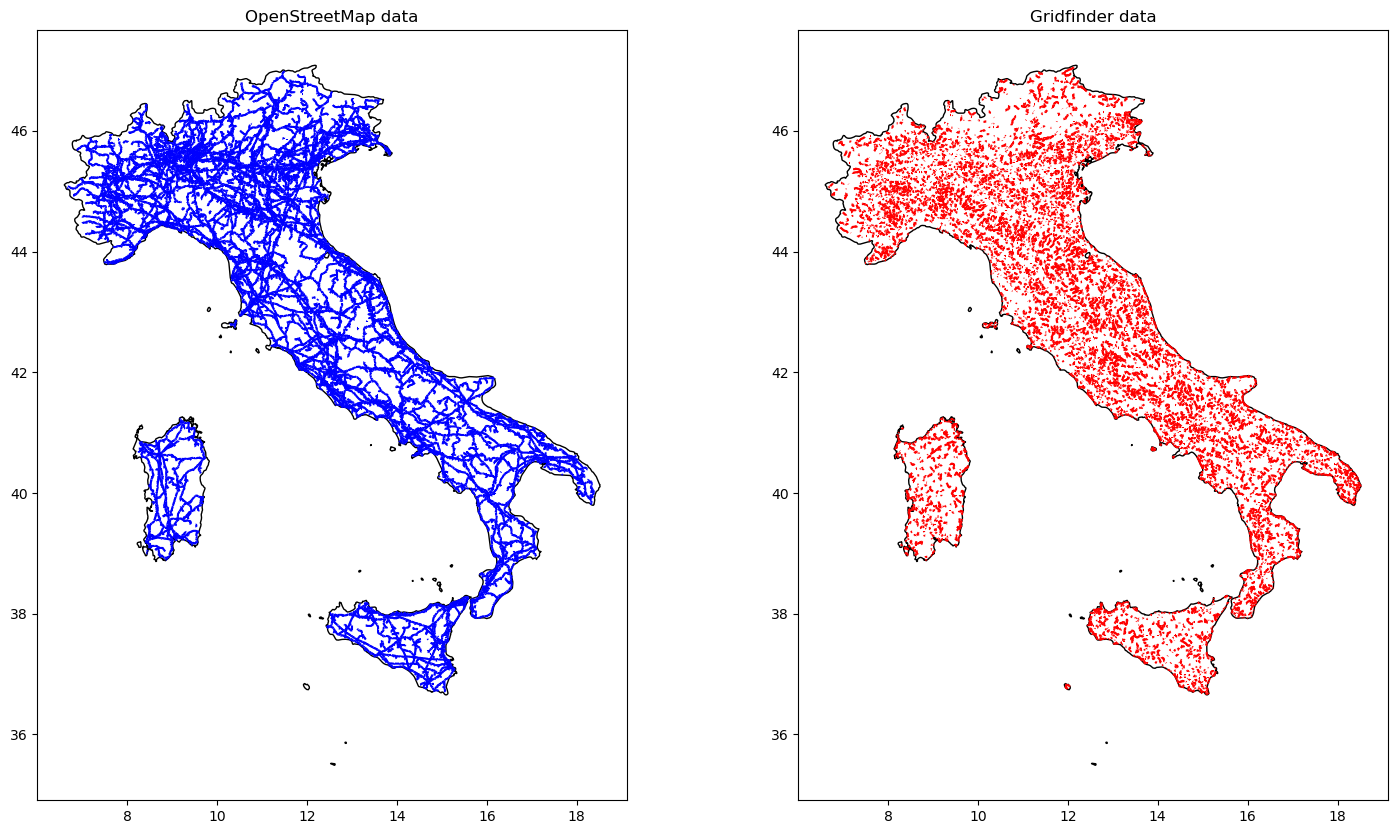

In [85]:
# polygon object that represent denmark's boundary
denmark_boundary = country_boundaries[country_boundaries['WB_NAME'] == 'Italy']

# Electrical grid of OSM data in Denmark
denmark_grid_o = gpd.clip(openstreetmap, denmark_boundary)
#  electrical grid of gridfinder in Denmark
denmark_grid_g = gpd.clip(gridfinder, denmark_boundary)

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(18, 10))

denmark_boundary.plot(ax=ax1, color='white', edgecolor='black')
denmark_grid_o.plot(ax=ax1, color='blue')
ax1.set_title('OpenStreetMap data')

denmark_boundary.plot(ax=ax2, color='white', edgecolor='black')
denmark_grid_g.plot(ax=ax2, color='red')
ax2.set_title('Gridfinder data')

plt.show()

To maximize the available data on power grids, both sources of information will be utilized. In general Openstreetmap power grid has more data compared to the gridfinder model, which has an accuracy rate of 70% at 1 km, so to maximize the available data on power grids both sources of information will be utilized.

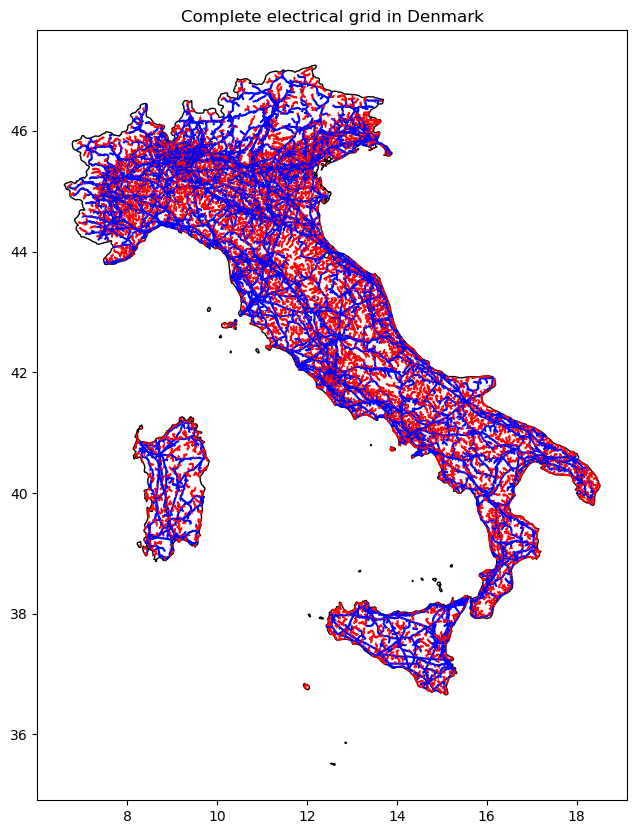

In [86]:
# Complete electrical grid in Denmark
denmark_grid = gpd.clip(data, denmark_boundary)

fig, ax = plt.subplots(figsize=(10, 10))
denmark_boundary.plot(ax=ax, color='white', edgecolor='black')
denmark_grid[denmark_grid['source'] == 'openstreetmap'].plot(ax=ax, color='blue')
denmark_grid[denmark_grid['source'] == 'gridfinder'].plot(ax=ax, color='red')

plt.title('Complete electrical grid in Italy')
plt.show()

# Potential locations for wind farms

To identify suitable areas of wind farms based on distance to existing electrical grids, an area,buffer zone of 15km around each transmission line was defined. For instance, the average distance from a wind farm to an electrical grid in the USA is typically 11-32 km and as it was said before the distance ultimately depends on many factors related to the wind farm project. 

The plot below illustrates that almost every area in Italy is a good location for a potential wind farm location based on the electrical grid parameter.

In [87]:
#Convert degrees to meters: Define the desired CRS
desired_crs = 'EPSG:3395'  #global projected CRS  suitable for displaying data.

# Reproject the GeoDataFrame to the desired CRS
denmark_grid_meters = denmark_grid.to_crs(desired_crs)
denmark_boundary_meters = denmark_boundary.to_crs(desired_crs)

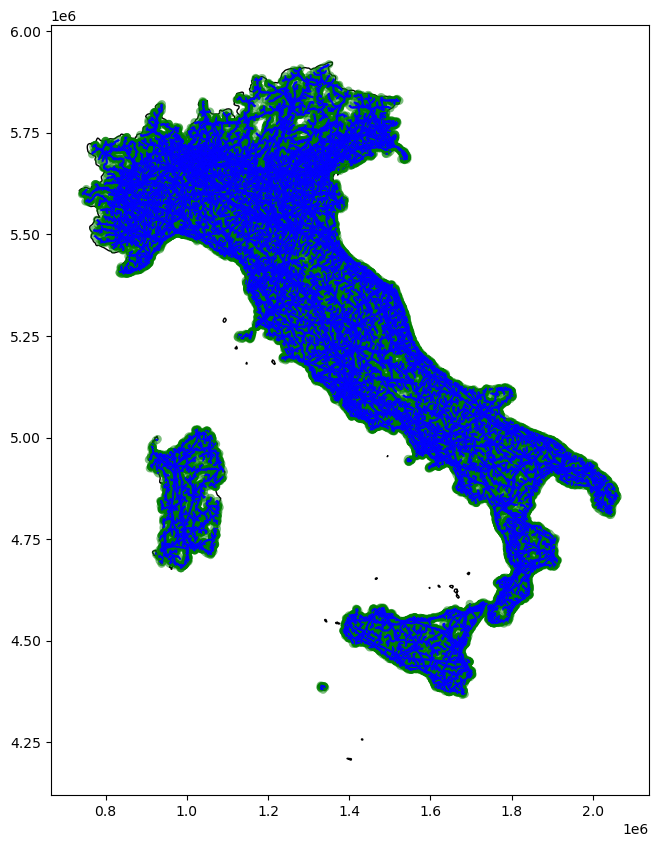

In [88]:
#buffer,area around electrical grid of Italy 15km (7.5km each side)
denmark_grid_buffer = denmark_grid_meters.buffer(10000)

fig, ax = plt.subplots(figsize=(10, 10))
denmark_boundary_meters.plot(ax=ax, color='white', edgecolor='black')
denmark_grid_meters.plot(ax=ax, color='blue')
denmark_grid_buffer.plot(ax=ax, color='green', alpha=0.5)

plt.show()

Function to determine the shortest distance between a potential wind farm and the nearest electrical grid. The function begins by identifying the appropriate coordinate system to represent the location of the proposed place. Next, it determines the country in which the point is located to limit the global electrical grid data to just that country. Finally, the function calculates the distances from the point to all electrical grids within the country and returns the closest one.

In [101]:
def min_dist_to_grid(df):
    
    
    # Initialize an empty list to store results
    minD = pd.DataFrame(columns=['proximity'])

    # Loop over rows in the input DataFrame
    for index, row in df.iterrows():
        # Get the longitude and latitude for the current row
        lat, lon = row['LAT'], row['LON']
    
        # create a GeoDataFrame with the point
        gdfp = gpd.GeoDataFrame(
            geometry=[shapely.geometry.Point(lon,lat)],
            crs="EPSG:4326")
        
        # calculate the UTM CRS that best fits the LineString's geometry
        utm = gdfp.estimate_utm_crs()

        # Find the name of the country that the coordinate belongs to
        country_name = None
        for i in range(len(country_boundaries)):
                if country_boundaries.iloc[i].geometry.contains(gdfp.geometry.iloc[0]):
                    country_name = country_boundaries.iloc[i]['WB_NAME']
                    break

                    
        # Check if the point is outside the borders of any country
        if country_name is None:
            # Find the name of the closest country that the coordinate belongs to
            dist_to_countries = []
            
            for i in range(len(country_boundaries)):
                dist = country_boundaries.iloc[i].geometry.distance(gdfp.geometry.iloc[0])
                dist_to_countries.append((dist, i))
            dist_to_countries.sort()
            closest_country_index = dist_to_countries[0][1]
            country_name = country_boundaries.iloc[closest_country_index]['WB_NAME']
            
            # Clip the grid to the boundary of the closest country
            boundary = country_boundaries[country_boundaries['WB_NAME'] == country_name]
            grid = gpd.clip(data, boundary)
            
            # project the Geodataframes into the UTM CRS
            gdfl_utm = grid['geometry'].to_crs(utm)
            gdfp_utm = gdfp.to_crs(utm)

            # iterate over each LineString and calculate the distance to the point
            min_dist = float('inf')
            for line in gdfl_utm.geometry:
                dist = line.distance(gdfp_utm.iloc[0].geometry)
                if dist < min_dist:
                    min_dist = dist

            print(f"Closest distance to any electrical grid is {min_dist:.2f} meters in {country_name}.")
    
                    
        else:
            #Creating the boundary and clipping the electrical grid of that country 
            boundary = country_boundaries[country_boundaries['WB_NAME'] == country_name]
            grid = gpd.clip(data, boundary)

            # project the Geodataframes into the UTM CRS
            gdfl_utm = grid['geometry'].to_crs(utm)
            gdfp_utm = gdfp.to_crs(utm)

            # iterate over each LineString and calculate the distance to the point
            min_dist = float('inf')
            for line in gdfl_utm.geometry:
                dist = line.distance(gdfp_utm.iloc[0].geometry)
                if dist < min_dist:
                    min_dist = dist

            print(f"Closest distance to any electrical grid is {min_dist:.2f} meters in {country_name}.")
            # Add result to the list of results
        
        minD = minD.append({'proximity': min_dist}, ignore_index=True)
    return minD

In [96]:
#Latitude, longitude
proximity_df=min_dist_to_grid(filtered_IT)


Closest distance to any electrical grid is 1360.73 meters in Italy.


Closest distance to any electrical grid is 364.14 meters in Italy.


Closest distance to any electrical grid is 164.44 meters in Italy.


Closest distance to any electrical grid is 231.94 meters in Italy.


Closest distance to any electrical grid is 132.55 meters in Italy.


...

Closest distance to any electrical grid is 300.70 meters in Italy.


Closest distance to any electrical grid is 3216.56 meters in Italy.


Closest distance to any electrical grid is 359.82 meters in Italy.


Closest distance to any electrical grid is 3471.80 meters in Italy.


Closest distance to any electrical grid is 482.74 meters in Italy.


In [98]:
proximity_df.head()

,proximity
0,1360.731790
1,364.144490
2,164.435939
3,231.940398
4,132.545945


In [102]:
filtered_IT = filtered_IT.join(proximity_df,rsuffix='_other')

In [106]:
filtered_IT.head()

,LUCA_LUSE_,NUTS_CODE,ELEV,AREA,EAST,NORT,LON,LAT,land use data,wspd,proximity
0,U361,ITF61,483,6651.20382,4872000,1908000,16.432834,40.056072,Non-irrigated arable land,9.510534,1360.731790
1,U340,ITF42,499,5131.69236,4834000,2018000,16.085300,41.075915,"Moors, heathland and sclerophyllous vegetation",7.355093,364.144490
2,U340,ITE44,10,2251.97078,4568000,2050000,12.947639,41.508231,"Moors, heathland and sclerophyllous vegetation",8.571448,164.435939
3,U340,ITE45,39,3238.15241,4640000,2050000,13.805810,41.479173,"Moors, heathland and sclerophyllous vegetation",7.206786,231.940398
4,U361,ITE43,441,5352.79290,4544000,2082000,12.673964,41.805307,Non-irrigated arable land,10.057409,132.545945


Different filters are applied to reduce the potential locations of wind farms, with the following values:
- Wind speed greater than 14.4 Km/h
- Geological terrain higher than 20m
- Proximity to the electrical grid less than 15km

In [111]:
potential_locations = filtered_IT[(filtered_IT['wspd'] > 14.4) & (filtered_IT['proximity'] < 15000) & (filtered_IT['ELEV'] > 20)]

In [114]:
potential_locations.shape

(18, 11)

In [112]:
import folium

# create a folium map object
m = folium.Map(location=[potential_locations['LAT'].mean(), potential_locations['LON'].mean()], zoom_start=3)

# add markers for each coordinate
for i in range(len(potential_locations)):
    folium.Marker([potential_locations.iloc[i]['LAT'], potential_locations.iloc[i]['LON']]).add_to(m)

# display the map
m

In [113]:
potential_locations.to_csv('Potential_locations.csv', index=False)